In [20]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16



In [21]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False,    # not take dense layer
    input_shape=(150,150,3),

)

In [22]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [23]:
model = Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [24]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_2 (Flatten)         (None, 8192)              0         
                                                                 
 dense_4 (Dense)             (None, 256)               2097408   
                                                                 
 dense_5 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 16,812,353
Non-trainable params: 0
_________________________________________________________________


In [25]:
conv_base.trainable = False

In [27]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_2 (Flatten)         (None, 8192)              0         
                                                                 
 dense_4 (Dense)             (None, 256)               2097408   
                                                                 
 dense_5 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 2,097,665
Non-trainable params: 14,714,688
_________________________________________________________________


In [30]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = 'archive/train',
    labels='inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (150,150)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = 'archive/test',
    labels='inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (150,150)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [31]:
# normalize
def process(image,label):
    image = tensorflow.cast(image/255.,tensorflow.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [32]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 [==============================] - 86s 112ms/step - loss: 0.2797 - accuracy: 0.8813 - val_loss: 0.2124 - val_accuracy: 0.9106
Epoch 2/10
625/625 [==============================] - 67s 107ms/step - loss: 0.1924 - accuracy: 0.9192 - val_loss: 0.2025 - val_accuracy: 0.9146
Epoch 3/10
625/625 [==============================] - 65s 104ms/step - loss: 0.1636 - accuracy: 0.9320 - val_loss: 0.2526 - val_accuracy: 0.9016
Epoch 4/10
625/625 [==============================] - 65s 104ms/step - loss: 0.1371 - accuracy: 0.9449 - val_loss: 0.2173 - val_accuracy: 0.9154
Epoch 5/10
625/625 [==============================] - 64s 102ms/step - loss: 0.1080 - accuracy: 0.9582 - val_loss: 0.2595 - val_accuracy: 0.9092
Epoch 6/10
625/625 [==============================] - 63s 101ms/step - loss: 0.0848 - accuracy: 0.9662 - val_loss: 0.2630 - val_accuracy: 0.9130
Epoch 7/10
625/625 [==============================] - 63s 101ms/step - loss: 0.0680 - accuracy: 0.9750 - val_loss: 0.2965 - val_ac

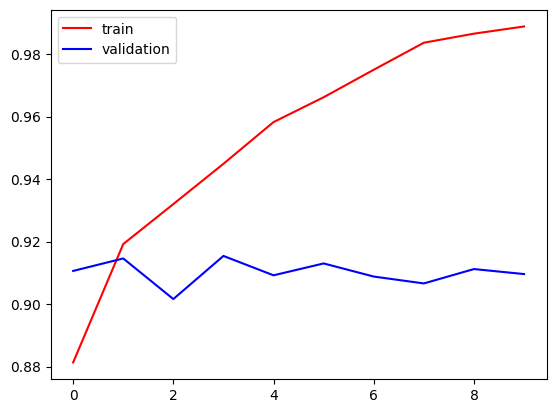

In [33]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

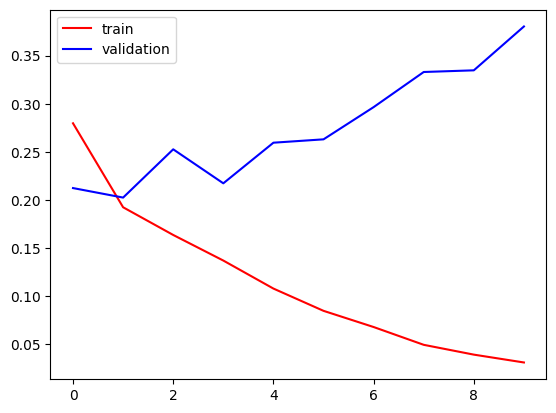

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()